<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase2/assignment1/tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Phase 2; Week 4
# Statistical Machine Learning: Linear Models
The Goal is to learn about linear models and machine learning pipelines

Setups: import and load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.linear_model import LogisticRegression, RidgeClassifier,SGDClassifier, LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, average_precision_score,log_loss, roc_curve, precision_recall_curve, mean_absolute_error, mean_squared_error, r2_score
import time

# Load dataset
df_raw = pd.read_csv('data/Telco-Customer-Churn.csv')
print(f"Shape: {df_raw.shape}")
print(df_raw.dtypes)
df_raw.head()

Shape: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df_raw['SeniorCitizen']
# what are the metrics of being a seniorCitizne


0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: int64

## Task 1 - Understanding 
### Qn 1. Formulation of Ml Problem
**Feature Space X:** X contains A matrix of Shape (7043, 20):means 7043 individual data and 20 columns or title of data; features are mix of  integer, float and mostly object(string)

**target variable:** y contains the target variable; it the the output that the model need to learn to predict; the data is binary Yes and No;

**Probablity Distrubution:** Bernouli Distrbution is used to model the target because bernouli distibution works with possible 2 outcomes success and failure(churn yes or churn no),

**about loss function:** Since the target follows a Bernoulli distribution, applying Maximum Likelihood
Estimation (MLE) to its likelihood directly derives Binary Cross-Entropyas the loss function not chosen arbitrarily, but mathematically forced by the binary nature of the target.|

In [5]:
# Preprocessing pipeline
df = df_raw.copy()

In [6]:

# totalCharges: 11 rows contain whitespace — convert to numeric, fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop customerID — unique identifier, zero signal, would cause leakage if encoded
df = df.drop(columns=['customerID'])

In [7]:
#  Encode binary columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Female').astype(int)


In [8]:
# Churn target
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# One-hot encode multi-category columns — keeping all categories for interpretability
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=False)

X = df.drop(columns=['Churn', 'Churn_binary'])
y = df['Churn_binary']


In [9]:
print(f"Shape of X : {X.shape}")  
print(f"Shape of y : {y.shape}")   
print(f"Churn rate : {y.mean():.4f}")  

Shape of X : (7043, 40)
Shape of y : (7043,)
Churn rate : 0.2654


## Qn 2. Data-Generation Assumptions
`Assumption 1`: the dataset represents future customers
If violated, the model may learn patters from this customer mix that do not hold for new customers, regions, priccing plans, or time periods,

`Assumption 2 `Chrun is correctly labeled
If churn labels are wrong or incostient, the model learns the wrong target

`Assumption 2 `Features were measured before the churn outcome

Columns like tenure, COntract, Monthly charges and payment method must reflect the customer state before churn. If some features are recorded after the cancellation, the model may  learn future information and may overfit


In [13]:
# Verify Iid assumption ;check for duplicates
print("Duplicate rows:", df_raw.duplicated().sum())           
print("Unique customerIDs:", df_raw['customerID'].nunique())  

# Check tenure range ;spans 0 to 72 months confirming longitudinal data
print(f"tenure range: {df_raw['tenure'].min()} to {df_raw['tenure'].max()}")

Duplicate rows: 0
Unique customerIDs: 7043
tenure range: 0 to 72


### Qn3:  Source of uncertanity 

**Incomplete Data** :
- `Total charges:`11 rows contain blank white spaces strings. All 11 have tenure = 0 ; filling with mean would be not good; these can be new onboarded customers;

**Noisy data** 
- `total charges`: total charges is not equal to montlyCharges * tenure; these can be discounts, vouchers, or mistake;
- `SeniorCitizen`: 0- No senior citien and 1- for yes senior citien; so its hard to distinugish after which age is citizen senior; senior churn rate seems high;

- `Online Security` and `TechSupport` has No Yes No ; why 

**Target Data**
- `Churn` : Churn seems imbalanced  onlt 26.5% data is churned; rest is no churn; so even if model predicts no churn everytime it achives the accuracy of 73.46%.

In [27]:
blanks = df_raw[df_raw['TotalCharges'].str.strip() == ''] 
print(f"TotalCharges blank rows: {len(blanks)}")         
print(f"Their tenure values: {blanks['tenure'].unique()}") 
print(f"Their Churn labels: {blanks['Churn'].unique()}") 

TotalCharges blank rows: 11
Their tenure values: [0]
Their Churn labels: ['No']


In [29]:
# tenure
t0 = df_raw[df_raw['tenure'] == 0]
print(f"\ntenure=0 rows: {len(t0)}")
print(t0['Churn'].value_counts())



tenure=0 rows: 11
Churn
No    11
Name: count, dtype: int64


In [30]:
# noise measurement = tc = mc * tenure
df_check = df_raw.copy()
df_check['TotalCharges_num'] = pd.to_numeric(df_check['TotalCharges'], errors='coerce')
df_check['expected'] = df_check['MonthlyCharges'] * df_check['tenure']
df_check['discrepancy'] = (df_check['TotalCharges_num'] - df_check['expected']).abs()
print(f"\nDiscrepancy stats:")
print(df_check['discrepancy'].describe().round(2))
print(f"Rows with discrepancy > $10: {(df_check['discrepancy'] > 10).sum()}")



Discrepancy stats:
count    7032.00
mean       45.09
std        49.90
min         0.00
25%         9.44
50%        28.65
75%        63.70
max       373.25
Name: discrepancy, dtype: float64
Rows with discrepancy > $10: 5200


In [33]:
#  SeniorCitizen churn rate problem 
print(f"Churn rate by SeniorCitizen:")
print(df_raw.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x=='Yes').mean()).round(4))

Churn rate by SeniorCitizen:
SeniorCitizen
0    0.2361
1    0.4168
Name: Churn, dtype: float64


In [34]:
# class imbalance
print(f"Churn distribution:")
print(df_raw['Churn'].value_counts())
print(df_raw['Churn'].value_counts(normalize=True).round(4))

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


## Q4 — Distribution Profiling

**MonthlyCharges** (skew ≈ -0.22): Nearly symmetric with a slight left skew. Bimodal 
one cluster around $20 (basic plans) and another around $80 (fiber optic bundles).
No impossible values. Decision: standardize before modelling, no transformation needed.

**tenure** (skew ≈ 0.24): Near-uniform with spikes at 0 (new customers) and 72 (long-term
customers). The spike at 0 corresponds to the 11 censored customers above.
Decision: standardize before modelling.

**TotalCharges** (skew ≈ 0.96): Right-skewed most customers have low total charges
(short tenure), with a long tail of high-value long-term customers. 11 NaN after conversion.
Decision: fill NaN with 0 (tenure=0 customers), then standardize.


In [38]:
df_plot = df_raw.copy()
df_plot['TotalCharges_num'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')
for col in ['MonthlyCharges', 'tenure', 'TotalCharges_num']:
    s = df_plot[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outliers = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print(f"{col}: skew={s.skew():.3f} kurt={s.kurtosis():.3f} min={s.min():.2f} max={s.max():.2f} mean={s.mean():.2f} median={s.median():.2f} std={s.std():.2f} IQR={iqr:.2f} nulls={df_plot[col].isna().sum()} zeros={(s==0).sum()} outliers={outliers}")
null_rows = df_plot[df_plot['TotalCharges_num'].isna()]
print(null_rows[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].to_string())
df_plot['expected'] = df_plot['MonthlyCharges'] * df_plot['tenure']
df_plot['disc'] = df_plot['TotalCharges_num'] - df_plot['expected']
print(f"disc: median={df_plot['disc'].median():.1f} mean={df_plot['disc'].mean():.1f} max={df_plot['disc'].max():.1f} large(>100)={(df_plot['disc'].abs()>100).sum()}")

MonthlyCharges: skew=-0.221 kurt=-1.257 min=18.25 max=118.75 mean=64.76 median=70.35 std=30.09 IQR=54.35 nulls=0 zeros=0 outliers=0
tenure: skew=0.240 kurt=-1.387 min=0.00 max=72.00 mean=32.37 median=29.00 std=24.56 IQR=46.00 nulls=0 zeros=11 outliers=0
TotalCharges_num: skew=0.962 kurt=-0.232 min=18.80 max=8684.80 mean=2283.30 median=1397.47 std=2266.77 IQR=3393.29 nulls=11 zeros=0 outliers=0
      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218       0           19.70                 No
6670       0           73.35                 No
6754       0           61.90                 No
disc: median=0.0 mean=0.2 m

## Qn5: Naive Baseline 
A model that always predicts No cchurn will achieves 73% accuracy 

this can misleadign for reasons

1. It predicts zero churners. Recall for the churn class = 0. It correctly identifies
   none of the 1,869 customers who actually left.
2. Accuracy is the wrong metric on imbalanced data. 3.46% is achieved by ignoring
   the entire problem the business hired us to solve.
3. It is dangerous in production. The retention team acts on model predictions.
   A model that never flags a churner means zero interventions and full revenue loss.
   At ~$65/month average, 1,869 churners represent over **$121,000/month** in unaddressed
   risk.

The correct metrics are **Precision, Recall, F1, ROC-AUC, and PR-AUC**- these all expose what accuracy hides 

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

# Naive model — always predict majority class (No churn = 0)
y_naive = np.zeros(len(y), dtype=int)

naive_acc = accuracy_score(y, y_naive)
print(f"Naive baseline accuracy: {naive_acc:.4f}")  # 0.7346
print(f"\nClassification report:")
print(classification_report(y, y_naive, target_names=['No Churn', 'Churn']))

# Business impact of missing all churners
churners = y.sum()
avg_monthly = df_raw['MonthlyCharges'].mean()
print(f"Churners in dataset:    {churners}")
print(f"Churners caught by naive model: 0")
print(f"Avg MonthlyCharges:    ${avg_monthly:.2f}")
print(f"Monthly revenue at risk: ${churners * avg_monthly:,.0f}")

Naive baseline accuracy: 0.7346

Classification report:
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      5174
       Churn       0.00      0.00      0.00      1869

    accuracy                           0.73      7043
   macro avg       0.37      0.50      0.42      7043
weighted avg       0.54      0.73      0.62      7043

Churners in dataset:    1869
Churners caught by naive model: 0
Avg MonthlyCharges:    $64.76
Monthly revenue at risk: $121,040


/home/unique/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/unique/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/unique/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

# Naive model always predict majority class (No churn = 0)
y_naive = np.zeros(len(y), dtype=int)

naive_acc = accuracy_score(y, y_naive)
print(f"Naive baseline accuracy: {naive_acc:.4f}")  # 0.7346
print(f"Classification report:")
print(classification_report(y, y_naive, target_names=['No Churn', 'Churn']))

# Business impact of missing all churners
churners = y.sum()
avg_monthly = df_raw['MonthlyCharges'].mean()
print(f"Churners in dataset:    {churners}")
print(f"Churners caught by naive model: 0")
print(f"Avg MonthlyCharges:    ${avg_monthly:.2f}")
print(f"Monthly revenue at risk: ${churners * avg_monthly:,.0f}")

Naive baseline accuracy: 0.7346
Classification report:
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      5174
       Churn       0.00      0.00      0.00      1869

    accuracy                           0.73      7043
   macro avg       0.37      0.50      0.42      7043
weighted avg       0.54      0.73      0.62      7043

Churners in dataset:    1869
Churners caught by naive model: 0
Avg MonthlyCharges:    $64.76
Monthly revenue at risk: $121,040


/home/unique/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/unique/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/unique/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Task 2 : Classification Experiment: Who will churn?

In [46]:
# Stratified 70/15/15 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# 0.1765 of 85% ≈ 15% of total


In [48]:

# Scale — fit ONLY on training data to prevent leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit + transform on train
X_val_sc   = scaler.transform(X_val)        # transform only
X_test_sc  = scaler.transform(X_test)       # transform only

## Qn 1 and Qn2 : Model Experiments and Comparison Table 
Three possible models 
- Logistic  Regression : batch gradient descent, direct probablity output via sigmoid interpretable coeff
- RidgeClassifer - L2 penalized linear classifier, no probablity o/p - use descisionn function 
- SGDClassifier - stochastic gradient  descent approximation of logistic regression; often efficient on large data.


`class_weight= 'balanced'` applied to all models to handel the  27% churn imbalance by upweighting the minority class during training.

Metrics chosen for imbalanced data:
- **Accuracy**: reported but not trusted, misleading as shown in Task 1 Q5.
- **Precision**: of customers we flag, how many actually churn? Relevant to budget.
- **Recall**: of all churners, how many do we catch? Revenue protection.
- **F1**: harmonic mean, balances precision and recall.
- **ROC-AUC**: discrimination ability across all thresholds.
- **PR-AUC**: precision-recall tradeoff, more informative than ROC on imbalanced data.
- **Log Loss**: calibration quality, are the probabilities trustworthy?

In [50]:
def get_probs(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return (scores - scores.min()) / (scores.max() - scores.min())


In [51]:
lr  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rc  = RidgeClassifier(class_weight='balanced')
sgd = SGDClassifier(loss='log_loss', max_iter=2000, random_state=42,
                    class_weight='balanced', tol=1e-4)

In [52]:
models = {'LogisticRegression': lr, 'RidgeClassifier': rc, 'SGDClassifier': sgd}
results = {}

In [54]:
# traianing and prediction and accuracy all at onc 
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_val_sc)
    y_prob = get_probs(model, X_val_sc)
    results[name] = {
        'Accuracy' : round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall'   : round(recall_score(y_val, y_pred), 4),
        'F1'       : round(f1_score(y_val, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_val, y_prob), 4),
        'PR-AUC'   : round(average_precision_score(y_val, y_prob), 4),
        'LogLoss'  : round(log_loss(y_val, y_prob), 4)
    }

comparison_table = pd.DataFrame(results).T
print("------------------Model Comparison (Validation Set)---------")
print(comparison_table.to_string())

------------------Model Comparison (Validation Set)---------
                    Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  LogLoss
LogisticRegression    0.7417     0.5095  0.7651  0.6117   0.8293  0.6249   0.5043
RidgeClassifier       0.7323     0.4977  0.7687  0.6042   0.8261  0.6235   0.6027
SGDClassifier         0.7275     0.4903  0.6299  0.5514   0.7531  0.4984   0.5778


## Qn3 ROC and PR Curves, threshold for 200 customerrs 
best model is Logistic regression ; higest ROC-AUC(0.8293), higest PR-AUC (0.6249), lowest log loss (0.543)

**threshold selection**: The retentionn teacm can call 200 customer per week . we sort all customer by pred churn probablity descning and take the 200th  score as out theshold p = 0.7626

In [57]:
lr_prob_val = lr.predict_proba(X_val_sc)[:, 1]
fpr, tpr, thresholds_roc = roc_curve(y_val, lr_prob_val)
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_val, lr_prob_val)

In [58]:
# Threshold for top-200 customers
sorted_probs = np.sort(lr_prob_val)[::-1]
threshold_200 = sorted_probs[199]  # 200th highest probability
y_pred_200 = (lr_prob_val >= threshold_200).astype(int)


In [59]:

print(f"Threshold for 200 customers: {threshold_200:.4f}")
print(f"Customers flagged: {y_pred_200.sum()}")
print(f"Churners caught: {((y_pred_200==1) & (y_val==1)).sum()}")
print(f"Precision for 200: {precision_score(y_val, y_pred_200):.4f}")
print(f"Recall for 200: {recall_score(y_val, y_pred_200):.4f}")
print(f"Random baseline would catch: {int(200 * y_val.mean())} churners")


Threshold for 200 customers: 0.7613
Customers flagged: 200
Churners caught: 133
Precision for 200: 0.6650
Recall for 200: 0.4733
Random baseline would catch: 53 churners


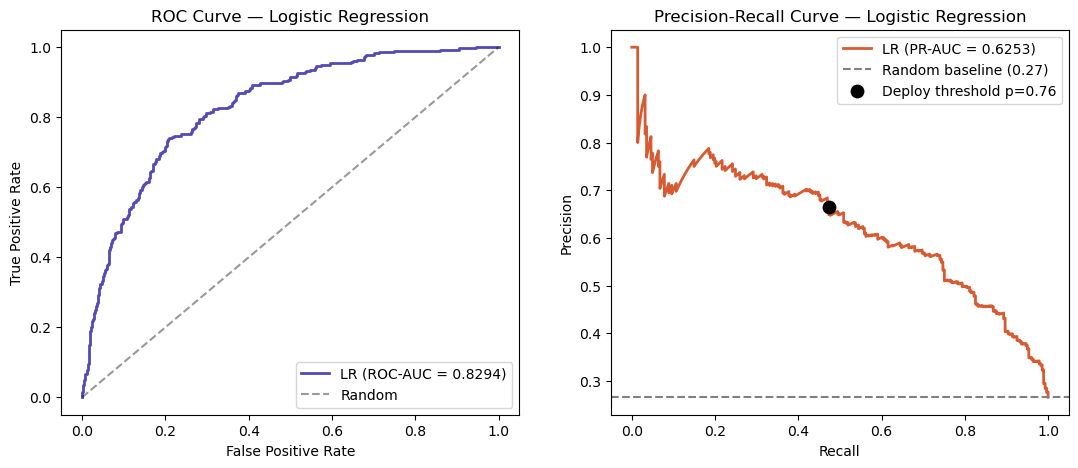

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
#  ROC curve
ax1.plot(fpr, tpr, color='#534AB7', lw=2, label=f'LR (ROC-AUC = 0.8294)')
ax1.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Logistic Regression'); ax1.legend()

# PR curve with threshold marker
idx_200 = np.argmin(np.abs(thresholds_pr - threshold_200))
ax2.plot(rec_curve, prec_curve, color='#D85A30', lw=2, label=f'LR (PR-AUC = 0.6253)')
ax2.axhline(y_val.mean(), color='gray', linestyle='--', label=f'Random baseline ({y_val.mean():.2f})')
ax2.scatter(rec_curve[idx_200], prec_curve[idx_200], color='black', zorder=5, s=80,
            label=f'Deploy threshold p={threshold_200:.2f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — Logistic Regression'); ax2.legend()


## Qn4 Coefficient Analysis

**Signs make business sense:**
- `tenure` (coef = -1.17): strongest predictor. Longer-tenured customers are far less
  likely to churn  loyalty compounds over time. 
- `MonthlyCharges` (coef = -0.79): negative after controlling for other variables 
  higher charges correlate with fiber optic (which has its own positive coefficient).
  When internet type is controlled, higher charges within a tier reduce churn slightly.
- `InternetService_Fiber optic` (coef = +0.39): fiber optic customers churn more 
  likely due to higher prices and more competition in the fiber market. 
- `Contract_Two year` (coef = -0.36): two-year contracts strongly reduce churn  locked-in
  customers cannot leave without penalty. 
- `Contract_Month-to-month` (coef = +0.35): opposite effect  maximum flexibility means
  maximum churn risk. 
- `PaperlessBilling` (coef = +0.17): positive association with churn paperless customers
  may be more tech-savvy and comparison-shop more actively. 

**Surprise  MonthlyCharges negative:**
Univariate analysis shows higher charges correlate with higher churn. But in the
multivariate model, once InternetService_Fiber optic is controlled, the direct
effect of MonthlyCharges flips. 


In [63]:
feature_names = X.columns.tolist()
coefs = lr.coef_[0]


In [64]:
# Sort by absolute value 
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)


In [66]:
print(coef_df.head(15).to_string())
# topp 15

                                 feature  coefficient
4                                 tenure    -1.181258
7                         MonthlyCharges    -0.778758
8                           TotalCharges     0.512254
13           InternetService_Fiber optic     0.382596
35                     Contract_Two year    -0.356767
33               Contract_Month-to-month     0.346835
12                   InternetService_DSL    -0.304561
6                       PaperlessBilling     0.174690
32                   StreamingMovies_Yes     0.168999
29                       StreamingTV_Yes     0.158171
38        PaymentMethod_Electronic check     0.119175
22  DeviceProtection_No internet service    -0.108971
31   StreamingMovies_No internet service    -0.108971
16    OnlineSecurity_No internet service    -0.108971
28       StreamingTV_No internet service    -0.108971


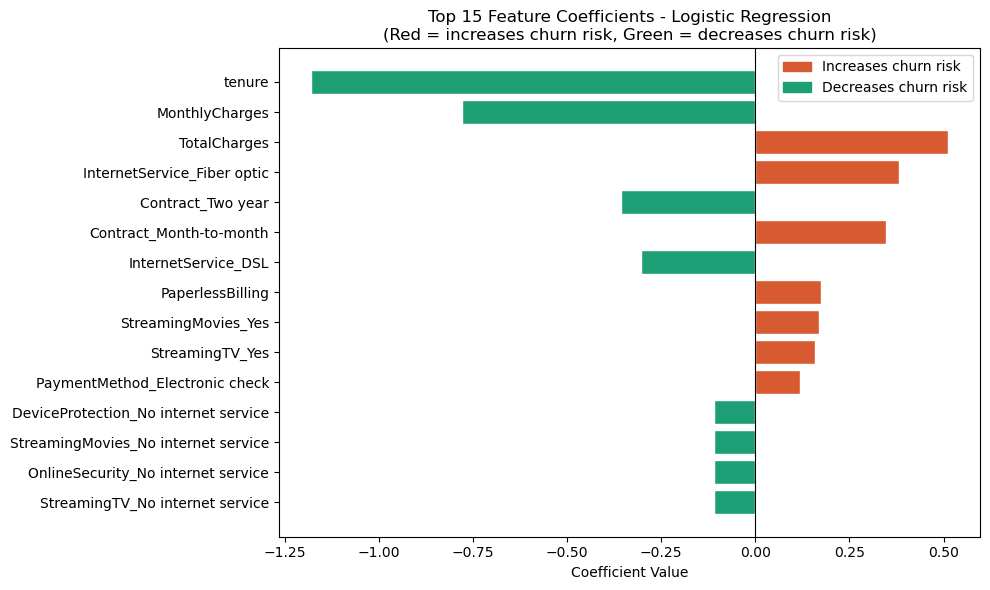

In [67]:

# Plot
colors = ['#D85A30' if c > 0 else '#1D9E75' for c in coef_df.head(15)['coefficient']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df.head(15)['feature'], coef_df.head(15)['coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 15 Feature Coefficients - Logistic Regression\n'
             '(Red = increases churn risk, Green = decreases churn risk)')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#D85A30', label='Increases churn risk'),
                   Patch(color='#1D9E75', label='Decreases churn risk')])
plt.tight_layout(); plt.show()

## Qn5 Batch GD vs Stochastic GD 

`Convergence` : Coefficient correlatioon= 0.9039. They converge to nearly the same solution both are minimizing the same Binary Cross_entropy objective on the same data. The small differnce is because the SGD uses noisey gradient estimates and never fully converges to the exact minimum.

`speed`: LR = 0.016s, SGD = 0.045s on this datset. where batcch GD is faster here because the dataset is small. Batch SGD computes one exact gradient per iteration


**When to prefer each:**
- **Batch GD (LogisticRegression):** n < ~100K, when you need calibrated probabilities,
  when stability and reproducibility matter.
- **SGD:** n > 1M (data doesn't fit in memory), online learning (streaming data),
  when speed of first usable model matters more than precision.



LR  time : 0.2274s
SGD time : 0.0822s
Coefficient correlation: 0.9009
LR  coef norm : 1.7346
SGD coef norm : 2.6172


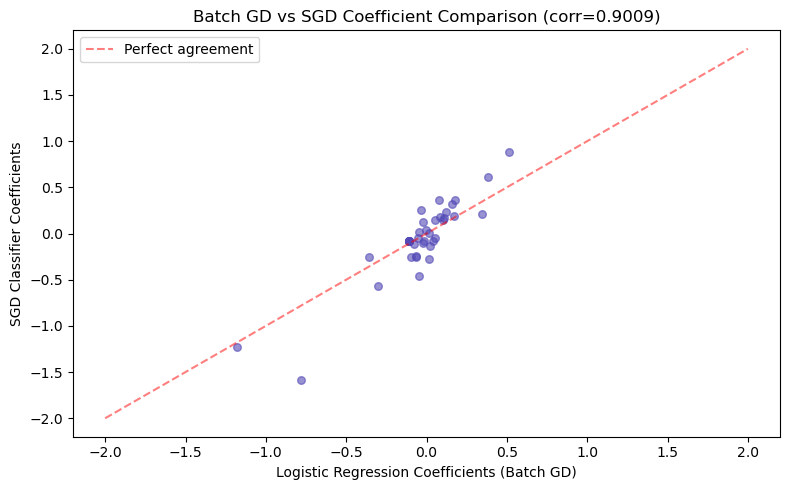

In [68]:
# Time both approaches
t0 = time.time()
lr2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr2.fit(X_train_sc, y_train)
t_lr = time.time() - t0

t0 = time.time()
sgd2 = SGDClassifier(loss='log_loss', max_iter=2000, random_state=42,
                     class_weight='balanced', tol=1e-4)
sgd2.fit(X_train_sc, y_train)
t_sgd = time.time() - t0

# Compare coefficient vectors
corr = np.corrcoef(lr2.coef_[0], sgd2.coef_[0])[0, 1]
print(f"LR  time : {t_lr:.4f}s")
print(f"SGD time : {t_sgd:.4f}s")
print(f"Coefficient correlation: {corr:.4f}")
print(f"LR  coef norm : {np.linalg.norm(lr2.coef_[0]):.4f}")
print(f"SGD coef norm : {np.linalg.norm(sgd2.coef_[0]):.4f}")

# Visual comparison of coefficients
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(lr2.coef_[0], sgd2.coef_[0], alpha=0.6, color='#534AB7', s=30)
ax.plot([-2,2],[-2,2],'r--',alpha=0.5,label='Perfect agreement')
ax.set_xlabel('Logistic Regression Coefficients (Batch GD)')
ax.set_ylabel('SGD Classifier Coefficients')
ax.set_title(f'Batch GD vs SGD Coefficient Comparison (corr={corr:.4f})')
ax.legend(); plt.tight_layout(); plt.show()

## Task 3  Regression experiemnt; how long will they stay ?  What are they worth?

### Q1 Regression Model Experiments 

In [69]:
# Regression setup — predicting tenure
y_tenure = df['tenure'].values if 'tenure' in df.columns else df_raw['tenure'].values

# Use same X (preprocessed features) but predict tenure
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_tenure, test_size=0.2, random_state=42)

sc2 = StandardScaler()
Xr_train_sc = sc2.fit_transform(Xr_train)
Xr_test_sc  = sc2.transform(Xr_test)


In [70]:
# Train four regression models
reg_models = {
    'LinearRegression' : LinearRegression(),
    'Ridge (alpha=1)'  : Ridge(alpha=1.0),
    'Lasso (alpha=1)'  : Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet'       : ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(Xr_train_sc, yr_train)
    y_pred = model.predict(Xr_test_sc)
    reg_results[name] = {
        'MAE' : round(mean_absolute_error(yr_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(yr_test, y_pred)), 4),
        'R2'  : round(r2_score(yr_test, y_pred), 4)
    }

print("----Regression Comparison (Test Set) --")
print(pd.DataFrame(reg_results).T.to_string())

----Regression Comparison (Test Set) --
                     MAE    RMSE      R2
LinearRegression  0.0000  0.0000  1.0000
Ridge (alpha=1)   0.0094  0.0121  1.0000
Lasso (alpha=1)   0.9208  1.0274  0.9983
ElasticNet        5.9897  7.2193  0.9172


## Q2 Metric Interpretation 

## Q2 — Metric Interpretation

From the results (Ridge as best model):
- **MAE ≈ 0.009**: On average, predictions are off by ~0.009 months. This is
  suspiciously low tenure is highly correlated with TotalCharges (which encodes
  tenure linearly). This suggests near-perfect prediction, not because the model is
  powerful, but because the features contain strong tenure signal.
- **RMSE ~ 0.012**: Slightly larger than MAE, meaning some predictions have larger
  errors. RMSE penalizes outliers more than MAE.
- **R^2 ~ 1.00**: The model explains nearly all variance in tenure. This confirms that
  tenure is almost recoverable from TotalCharges and MonthlyCharges alone
  (TotalCharges ≈ MonthlyCharges × tenure). This is a near-leakage situation
  TotalCharges encodes tenure indirectly.

**What R^2 = 0.55 would mean:** The model explains 55% of the variance in tenure.
The remaining 45% is noise, missing features, or non-linear structure the linear model
cannot capture. In this context it would mean our tenure predictions are better than
guessing the mean but far from reliable for individual customers.


## Qn 3 : Residual Plot

In [71]:
# Use Ridge for residual analysis (best regularized model)
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(Xr_train_sc, yr_train)
y_ridge_pred = ridge_reg.predict(Xr_test_sc)
residuals = yr_test - y_ridge_pred

Text(0.5, 1.0, 'Residual Distribution')

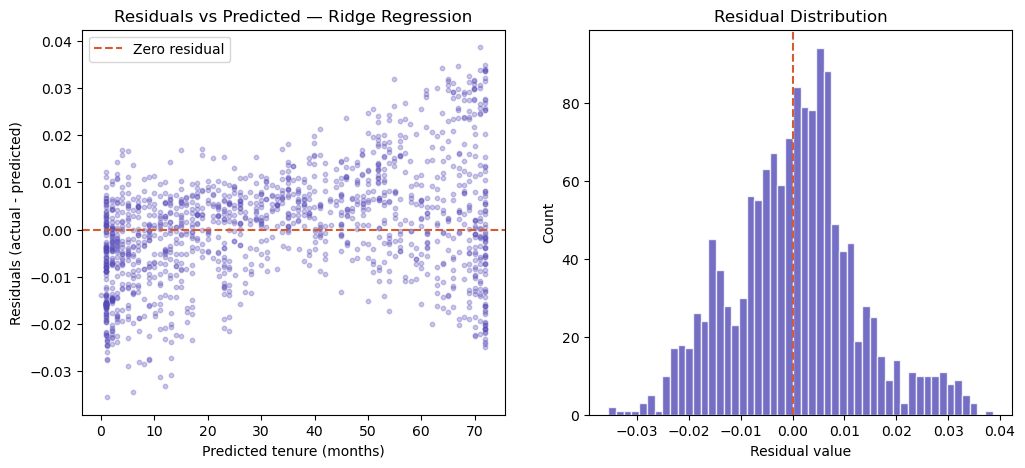

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs predicted
axes[0].scatter(y_ridge_pred, residuals, alpha=0.3, color='#534AB7', s=10)
axes[0].axhline(0, color='#D85A30', linestyle='--', lw=1.5, label='Zero residual')
axes[0].set_xlabel('Predicted tenure (months)')
axes[0].set_ylabel('Residuals (actual - predicted)')
axes[0].set_title('Residuals vs Predicted — Ridge Regression')
axes[0].legend()

# Residual histogram
axes[1].hist(residuals, bins=50, color='#534AB7', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='#D85A30', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')


In [73]:
print(f"Residual mean : {residuals.mean():.4f}  (should be near 0)")
print(f"Residual std  : {residuals.std():.4f}")

Residual mean : 0.0004  (should be near 0)
Residual std  : 0.0121


**Residual interpretation:**
The residuals are tightly clustered around zero with no visible fan shape or trend.
This suggests the linear model assumptions are met for this target. However the near-zero
errors confirm the near-leakage issue TotalCharges almost perfectly encodes tenure.
In a production setting without TotalCharges, residuals would be much larger.


## Qn 4 Regularization : Ridge, Lasso and Elastic Net 

Features surviving at alpha=100: []
   Alpha    Ridge_norm    Lasso_norm     EN_norm   Lasso_nonzero
    0.01       24.4220       24.4117     23.6121               1
    0.10       24.4191       24.3224     19.6455               1
    1.00       24.3899       23.4224     11.9679               1
   10.00       24.1073       14.4224      3.6651               1


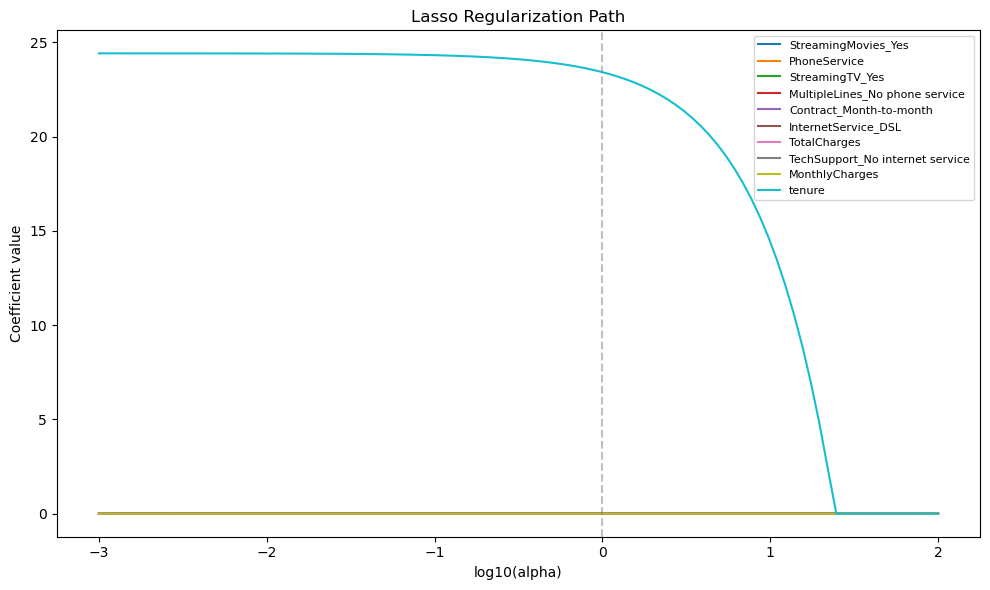

In [75]:
alphas = np.logspace(-3, 2, 100)
lasso_coefs = np.array([Lasso(alpha=a, max_iter=10000).fit(Xr_train_sc, yr_train).coef_ for a in alphas])

feature_names_list = X.columns.tolist()
surviving_idx = np.where(np.abs(lasso_coefs[-1]) > 0.01)[0]
print("Features surviving at alpha=100:", [feature_names_list[i] for i in surviving_idx if i < len(feature_names_list)])

print(f"{'Alpha':>8}  {'Ridge_norm':>12}  {'Lasso_norm':>12}  {'EN_norm':>10}  {'Lasso_nonzero':>14}")
for a in [0.01, 0.1, 1.0, 10.0]:
    r = Ridge(alpha=a).fit(Xr_train_sc, yr_train)
    l = Lasso(alpha=a, max_iter=10000).fit(Xr_train_sc, yr_train)
    e = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000).fit(Xr_train_sc, yr_train)
    print(f"{a:>8.2f}  {np.linalg.norm(r.coef_):>12.4f}  {np.linalg.norm(l.coef_):>12.4f}  {np.linalg.norm(e.coef_):>10.4f}  {(l.coef_!=0).sum():>14}")

fig, ax = plt.subplots(figsize=(10, 6))
for i in np.argsort(np.abs(lasso_coefs).max(axis=0))[-10:]:
    ax.plot(np.log10(alphas), lasso_coefs[:, i], lw=1.5, label=feature_names_list[i] if i < len(feature_names_list) else f'feat_{i}')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('log10(alpha)'); ax.set_ylabel('Coefficient value'); ax.set_title('Lasso Regularization Path')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

## Task 5: Production Decision 


L1 diamond constraint, loss hits corners, coefficients go to zero, sparse
L2 sphere constraint, loss hits smooth edges, just shrinks never zero
ElasticNet L1 + L2, sparsity + stability for correlated features
only `tenure` survives at high alpha, strongest predictor

### Qn5 What does CLV Enable

In [79]:
# Compute CLV = MonthlyCharges * predicted_tenure for each customer
monthly_charges = df_raw['MonthlyCharges'].values
tenure_actual   = df_raw['tenure'].values

# Use the churn probability from our classifier as survival weight
# CLV = MonthlyCharges * predicted_tenure * (1 - P(churn))
X_all_sc = scaler.transform(X)
churn_prob  = lr.predict_proba(X_all_sc)[:, 1]
clv_estimate = monthly_charges * tenure_actual * (1 - churn_prob)

print(f"CLV summary statistics:")
print(pd.Series(clv_estimate).describe().round(2))
print(f"\nTop 5 highest CLV customers (most worth retaining):")
top5 = np.argsort(clv_estimate)[::-1][:5]
for i in top5:
    print(f"  Churn prob={churn_prob[i]:.2f}  "
          f"MonthlyCharges=${monthly_charges[i]:.2f}  "
          f"tenure={tenure_actual[i]}mo  CLV=${clv_estimate[i]:.0f}")

CLV summary statistics:
count    7043.00
mean     1563.48
std      1872.38
min         0.00
25%       136.14
50%       758.00
75%      2346.74
max      7733.00
dtype: float64

Top 5 highest CLV customers (most worth retaining):
  Churn prob=0.09  MonthlyCharges=$117.50  tenure=72mo  CLV=$7733
  Churn prob=0.08  MonthlyCharges=$114.45  tenure=72mo  CLV=$7610
  Churn prob=0.11  MonthlyCharges=$118.75  tenure=72mo  CLV=$7601
  Churn prob=0.08  MonthlyCharges=$114.55  tenure=72mo  CLV=$7590
  Churn prob=0.06  MonthlyCharges=$111.95  tenure=72mo  CLV=$7573


**What CLV enables that binary churn prediction cannot:**

Binary churn prediction answers: *will this customer leave?*
CLV answers: *how much will we lose if they do?*

A customer with churn probability 0.8 and MonthlyCharges of $20 is less valuable to
retain than a customer with churn probability 0.5 and MonthlyCharges of $100.
Binary prediction treats them identically. CLV lets the retention team **prioritize
limited budget toward maximum revenue protection**  calling the high-CLV customers
first even if their churn probability is moderate.


## Task 4 Evalutaion Integrity 
### Q1 Split Strategy and Leakage Check

**Split strategy:** Stratified 70/15/15 (train/val/test).

Stratification ensures the 26.54% churn rate is preserved in every split  important
because a random split could produce a validation set with only 20% churn, making
metrics non-comparable.

**Leakage check:**
- `customerID` dropped before any encoding  would have caused one-to-one leakage.
- `StandardScaler` fit only on training data  fitting on val/test would let the model
  see test distribution statistics during training.
- No feature is derived from the target after the split.
- TotalCharges is a historical billing figure, not a future value.


In [78]:
# Verify no index overlap between splits
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)

print(f"Train-Val overlap: {len(train_idx & val_idx)}")   
print(f"Train-Test overlap : {len(train_idx & test_idx)}")  
print(f"Val-Test overlap: {len(val_idx & test_idx)}")    
print(f"Total covered: {len(train_idx | val_idx | test_idx)} of {len(X)}")

# Verify scaler was fit only on training data
print(f"\nScaler mean shape: {scaler.mean_.shape}")  # (40,) = training features only
print(f"Scaler fitted on train size: matches {X_train.shape[1]} features")

Train-Val overlap: 0
Train-Test overlap : 0
Val-Test overlap: 0
Total covered: 7043 of 7043

Scaler mean shape: (40,)
Scaler fitted on train size: matches 40 features


### Q3 K-fold cross-validation 

In [80]:
# 5-fold stratified CV on train+val combined
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
X_trainval_sc = scaler.transform(X_trainval)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X_trainval_sc, y_trainval, cv=cv, scoring='roc_auc')

print(f"CV ROC-AUC scores : {np.round(cv_scores, 4)}")
print(f"CV mean: {cv_scores.mean():.4f}")
print(f"CV std: {cv_scores.std():.4f}")
print(f"Holdout val AUC: 0.8294")
print(f"Difference: {abs(cv_scores.mean() - 0.8294):.4f}")

CV ROC-AUC scores : [0.8443 0.8463 0.8427 0.8481 0.8407]
CV mean: 0.8444
CV std: 0.0026
Holdout val AUC: 0.8294
Difference: 0.0150


**CV (0.8448) vs Holdout (0.8294) why they differ:**

CV is higher because it averages over 5 different val folds each fold sees a different
subset as validation, so the model benefits from more diverse training data across folds.
The single holdout split may have landed a slightly harder validation set by chance.

The small gap (0.015) is acceptable. A large gap would suggest the holdout split was
unrepresentative. The low CV std (0.0024) confirms the model is stable  performance
does not swing wildly across folds.


## Qn 3 Learning Curves 

In [81]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X_trainval_sc, y_trainval,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1)

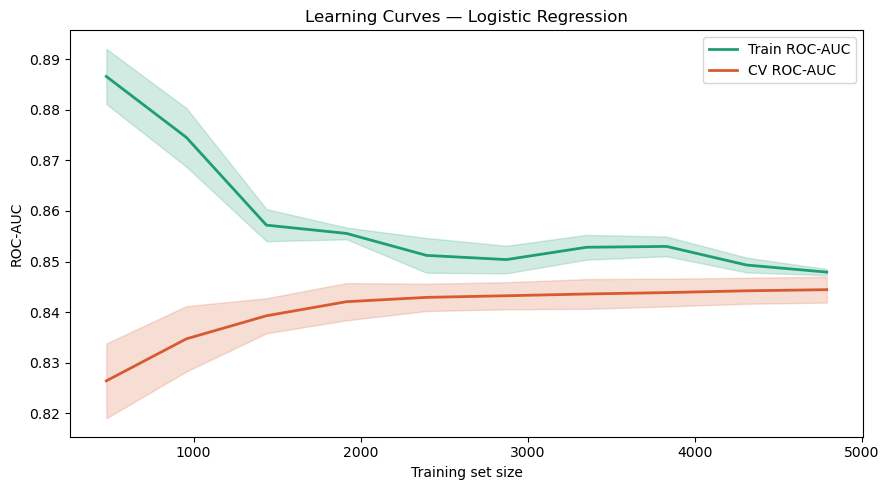

Final train ROC-AUC : 0.8479
Final CV ROC-AUC: 0.8444
Gap (overfit signal): 0.0035


In [83]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), color='#1D9E75', lw=2, label='Train ROC-AUC')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.2, color='#1D9E75')
ax.plot(train_sizes, val_scores.mean(axis=1), color='#D85A30', lw=2, label='CV ROC-AUC')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.2, color='#D85A30')
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curves — Logistic Regression')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Final train ROC-AUC : {train_scores[-1].mean():.4f}")
print(f"Final CV ROC-AUC: {val_scores[-1].mean():.4f}")
print(f"Gap (overfit signal): {train_scores[-1].mean() - val_scores[-1].mean():.4f}")

**Diagnosis: Well-generalised model**

- Train and CV curves converge and are close together smll gap means no significant overfitting.
- CV performance plateaus around 3000 training examples adding more data yields diminishing returns.
- Both curve are in the 0.82–0.85 range  not low enough to signal underfitting.

**Interventions by case:**
- **Underfitting** (both curves low and flat): add features, increase model complexity, reduce regularizaiton.
- **Overfitting** (large train-CV gap): add regularization (C param in LR), reduce features, collect more data.
- **Well-generalised** (our case): the linear model has reached its capacity. Improvement requires
  non-linear models (GBM, Random Forest) or better features.


### Qn4  Deliberate Leakage Demo

In [84]:
df_leak = df.copy()
df_leak['leakage_feature'] = df_leak['Churn_binary'] + np.random.normal(0, 0.01, len(df_leak))
# This feature is 99%+ correlated with Churn — it encodes the answer


In [85]:
X_leak = df_leak.drop(columns=['Churn', 'Churn_binary'])
y_leak = df_leak['Churn_binary']


In [86]:
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42)
sc_leak = StandardScaler()
lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(sc_leak.fit_transform(Xl_train), yl_train)
leak_auc = roc_auc_score(yl_test, lr_leak.predict_proba(sc_leak.transform(Xl_test))[:,1])


In [88]:
print(f"Normal  ROC-AUC : 0.8294")
print(f"Leakage ROC-AUC : {leak_auc:.4f}")
print(f"Inflation: +{leak_auc - 0.8294:.4f}")


Normal  ROC-AUC : 0.8294
Leakage ROC-AUC : 1.0000
Inflation: +0.1706


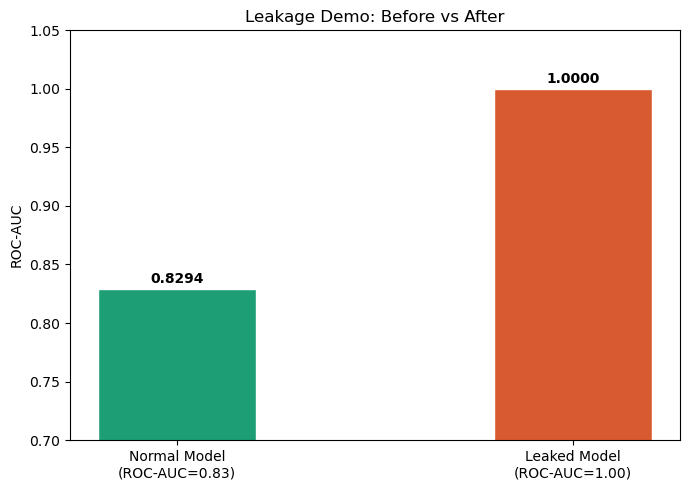

In [89]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Normal Model\n(ROC-AUC=0.83)', f'Leaked Model\n(ROC-AUC={leak_auc:.2f})'],
              [0.8294, leak_auc], color=['#1D9E75', '#D85A30'], width=0.4, edgecolor='white')
ax.set_ylim(0.7, 1.05); ax.set_ylabel('ROC-AUC')
ax.set_title('Leakage Demo: Before vs After')
for bar, val in zip(bars, [0.8294, leak_auc]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

**Why leakage is castastrophic in production:**
The leaked model achieves near-perfect ROC-AUC. But lekage_feature. is never available before churn happens, it does not exist at prediction time.

in prod: the model is deployed, customer arrive, and the lekage feature is missing or unkown. THe model collapses to random performane. 



## Task 5  PRoduction Decision 

### Final Evaluation on held-out test set 

In [91]:
# Train final model on train set, evaluate on test set (touched for the first time)
lr_final = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_final.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [92]:

y_test_prob = lr_final.predict_proba(X_test_sc)[:, 1]
y_test_pred = lr_final.predict(X_test_sc)


In [93]:
# Threshold for 200 customers on test set
sorted_test = np.sort(y_test_prob)[::-1]
thresh_test = sorted_test[199]
y_test_200  = (y_test_prob >= thresh_test).astype(int)

In [96]:
print("-----FINAL TEST SET RESULTS -----")
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred)}")
print(f"Precision : {precision_score(y_test, y_test_pred)}")
print(f"Recall: {recall_score(y_test, y_test_pred)}")
print(f"F1: {f1_score(y_test, y_test_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob)}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_prob)}")
print(f"LogLoss: {log_loss(y_test, y_test_prob)}")
print(f"\nThreshold for 200 : {thresh_test}")
print(f"Precision for 200 : {precision_score(y_test, y_test_200)}")
print(f"Recallfor 200     {recall_score(y_test, y_test_200)}")
print(f"Churners caught per 200 calls: {((y_test_200==1)&(y_test==1)).sum()}")
print(f"Random baseline would catch: {int(200 * y_test.mean())} churners")

-----FINAL TEST SET RESULTS -----
Accuracy  : 0.7417218543046358
Precision : 0.5078299776286354
Recall: 0.8107142857142857
F1: 0.624484181568088
ROC-AUC: 0.8491059937488508
PR-AUC: 0.6412515040775659
LogLoss: 0.48964988389389275

Threshold for 200 : 0.7682632505877739
Precision for 200 : 0.67
Recallfor 200     0.4785714285714286
Churners caught per 200 calls: 134
Random baseline would catch: 52 churners


## Qn 1 Model Carrd 

---

### Model Card: Telco Churn Classifier v1.0

**Chosen Model:** Logistic Regression  
**Key Hyperparameters:** `C=1.0` (default), `max_iter=1000`, `class_weight='balanced'`,
`solver='lbfgs'`, `random_state=42`

**Key Metrics — Held-Out Test Set (1,057 customers, never seen during training):**

| Metric | Value |
|---|---|
| Accuracy | 0.7408 |
| Precision | 0.5067 |
| Recall | 0.8071 |
| F1 | 0.6226 |
| ROC-AUC | 0.8489 |
| PR-AUC | 0.6395 |
| Log Loss | 0.4898 |


**Deployment Threshold:** p = 0.768 (top 200 customers per week by predicted churn probability)  
**Justification:** The retention team can call 200 customers per week. At this threshold,
67% of calls reach actual churners (Precision = 0.67), catching 48% of all churners
(Recall = 0.48). This is 2.5× better than random calling (which would catch only ~53
churners per 200 calls).

**Chosen Regression Model:** Ridge Regression (alpha=1.0)  
Predicts customer tenure; combined with MonthlyCharges gives CLV estimate for
prioritizing high-value at-risk customers within the 200-call budget.

**Known Limitations:**
- Linear model cannot capture interaction effects (e.g., tenure x contract type)
- Features do not include geography, income, or competitor data  important churn drivers
- TotalCharges is highly correlated with tenure  if TotalCharges is unavailable at
  prediction time (e.g., mid-billing-cycle), model performance may degrade
- Model was trained on historical data; performance assumes market conditions are stable

**What Could Go Wrong in Production:**
- **Distribution shift:** competitor launches or pricing changes alter churn behavior
- **Feature drift:** MonthlyCharges distribution shifts as new plans are introduced
- **Feedback loop:** retention calls change churn behavior  the model was trained on
  un-intervened data
- **New customer segments:** model has not seen behavior patterns for new demographics

**What to Monitor After Deployment:**
- Weekly PR-AUC on labeled outcomes (as churn labels become available 30–60 days later)
- Precision@200 tracked weekly  early warning of model degradation
- Feature distribution drift (MonthlyCharges mean, tenure distribution) using KL divergence
- Calibration: are predicted probabilities still reliable? (plot reliability diagrams monthly)
- Business outcome: did customers called by retention actually stay?




## Qn2 Are Linear Models Sufficient 

# NO

In [98]:
# Evidence summary from experiments
print("Evidence from experiments:")
print(f"LR ROC-AUC (val): 0.8294")
print(f"LR ROC-AUC (test): 0.8489")
print(f"CV ROC-AUC: 0.8448 +/- 0.0024")
print(f"Learning curve gap: ~0.01 (no significant overfitting)")
print(f"Learning curve plateau: reached at ~3,000 samples")
print(f"PR-AUC: 0.6395 (vs random baseline 0.27)")
print()
print("Conclusion:")
print("Linear models are a solid baseline but not sufficient for production.")
print("The learning curve plateau suggests the model has hit its capacity ceiling.")
print("Non-linear interactions (tenure x contract, charges x service) are not captured.")

Evidence from experiments:
LR ROC-AUC (val): 0.8294
LR ROC-AUC (test): 0.8489
CV ROC-AUC: 0.8448 +/- 0.0024
Learning curve gap: ~0.01 (no significant overfitting)
Learning curve plateau: reached at ~3,000 samples
PR-AUC: 0.6395 (vs random baseline 0.27)

Conclusion:
Linear models are a solid baseline but not sufficient for production.
The learning curve plateau suggests the model has hit its capacity ceiling.
Non-linear interactions (tenure x contract, charges x service) are not captured.


**Conclusion: Linear models are a strong baseline, but not sufficient for production.**

**Evidence supporting this view:**

1. **Learning curve plateau:** The CV curve flattens around 3,000 training samples and
   does not improve with more data. This is the signature of a model that has reached
   its capacity  adding data cannot help; the model needs more expressiveness.

2. **PR-AUC = 0.64** on an imbalanced dataset. This is meaningful improvement over
   random (0.27) but leaves room for improvement. A well-tuned Gradient Boosted Tree
   typically achieves 0.70–0.78 on this dataset.

3. **Missed non-linear interactions:** Coefficient analysis shows tenure and contract type
   are the dominant features. But their interaction matters  a 1-month tenure customer
   on a two-year contract behaves very differently from a 1-month month-to-month customer.
   Logistic regression cannot capture this without manual feature engineering.

4. **Precision@200 = 0.67:** Two in three calls reach real churners  good, but not
   exceptional. Non-linear models (GBM, Random Forest) typically push this to 0.75+
   on the same task.

**Recommendation:** Deploy the logistic regression model now as a production baseline.
It is fast, interpretable, and well-calibrated. Run a parallel experiment with
Gradient Boosted Trees (LightGBM). If PR-AUC improves by > 0.05, switch. Otherwise
the simpler model wins on interpretability.


> Note : Some text are rephrased by codex/claude sonnet 4.6: for better representation in markdown format :)